In [38]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from pathlib import Path

pd.set_option('display.max_columns', None)

# Download dataset and get path
dataset_path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")

# Find CSV file(s) in the dataset
csv_files = list(Path(dataset_path).rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {dataset_path}")

# Load first CSV (or combine multiple if needed, e.g. Fake.csv + True.csv)
# index_col=0 skips the "Unnamed: 0" column (saved index from original CSV)
if len(csv_files) == 1:
    df = pd.read_csv(csv_files[0], index_col=0)
else:
    # If dataset has separate Fake.csv and True.csv, load and combine
    dfs = []
    for f in csv_files:
        dfs.append(pd.read_csv(f, index_col=0))
    df = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(df)} rows from {[f.name for f in csv_files]}")
df.head()

# Label (0 = fake and 1 = real) 

Loaded 72134 rows from ['WELFake_Dataset.csv']


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [39]:
df_cleaned = df[~df.isna().any(axis = 1)].copy()
df_cleaned['text'] = df_cleaned['title'].str.strip() + ". " + df_cleaned['text'].str.strip()

In [40]:
label_map = {
    0: 'Real',
    1: 'Fake'
}
df_cleaned['label_name'] = df_cleaned['label'].map(label_map)

In [41]:
df_cleaned['label'].value_counts(normalize=True)

label
1    0.510351
0    0.489649
Name: proportion, dtype: float64

count    71537.000000
mean       556.828508
std        626.527077
min          2.000000
10%        100.000000
25%        244.000000
50%        412.000000
75%        683.000000
90%       1118.000000
95%       1432.000000
max      24243.000000
Name: text, dtype: float64


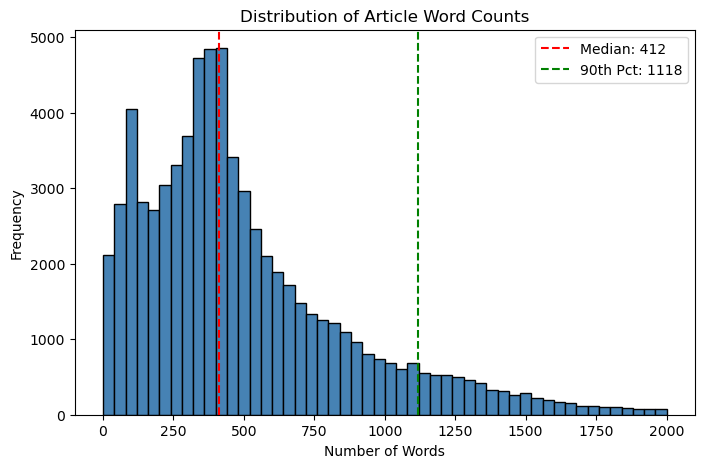

In [42]:
word_counts = df_cleaned['text'].apply(lambda x: len(str(x).split())) 
print(word_counts.describe(percentiles=[0.1, 0.25, 0.50, 0.75, 0.90, 0.95])) 

plt.figure(figsize=(8, 5))
plt.hist(word_counts, bins=50, range=(0, 2000), color='steelblue', edgecolor='black')
plt.title('Distribution of Article Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

# Plot reference lines for the Median and 90th Percentile
median_val = word_counts.median()
p90_val = word_counts.quantile(0.90)

plt.axvline(median_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Median: {median_val:.0f}')
plt.axvline(p90_val, color='green', linestyle='dashed', linewidth=1.5, label=f'90th Pct: {p90_val:.0f}')
plt.legend()
plt.show()

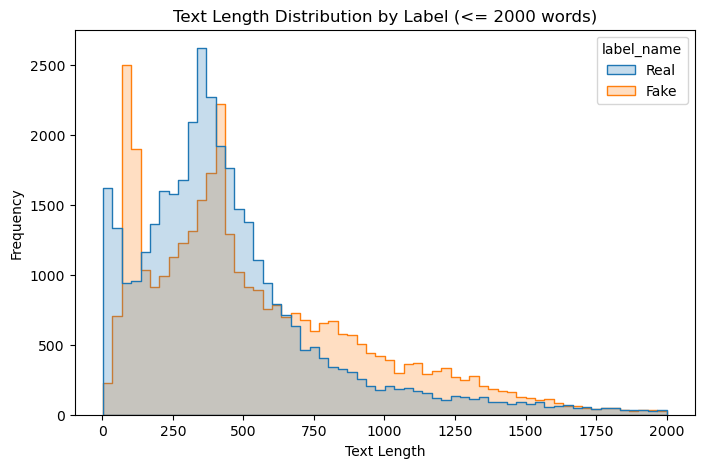

In [46]:

import seaborn as sns
import matplotlib.pyplot as plt

# explicit mapping
df_cleaned['label_name'] = df_cleaned['label'].map({
    0: 'Fake',
    1: 'Real'
})

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_cleaned[df_cleaned['text_length'] <= 2000],
    x='text_length',
    hue='label_name',
    bins=60,
    element='step',
    stat='count',
    common_norm=False
)

plt.title('Text Length Distribution by Label (<= 2000 words)')
plt.xlabel('Text Length')
plt.ylabel('Frequency')

plt.show()

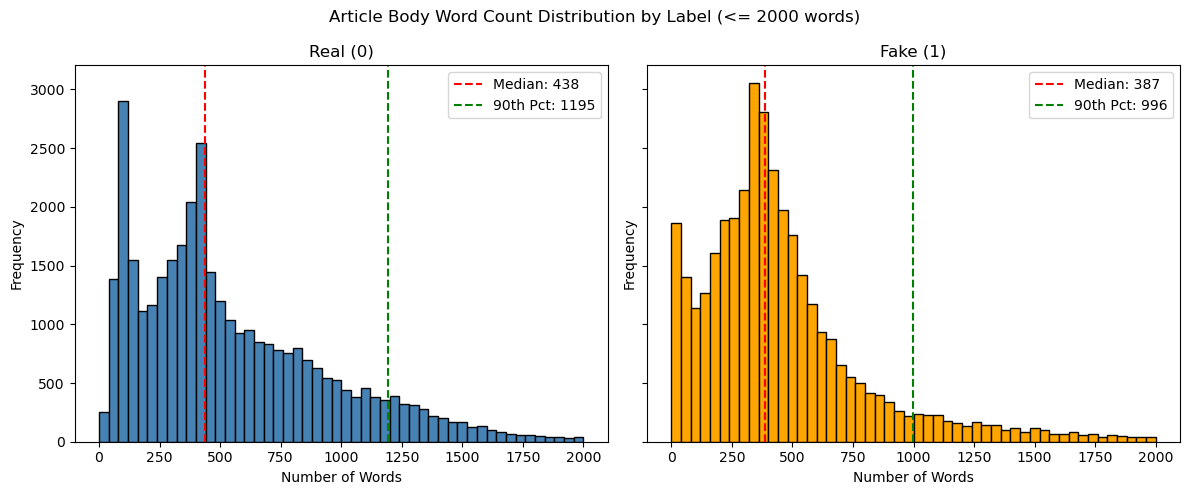

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

labels_map = {0: 'Real (0)', 1: 'Fake (1)'}
colors = {0: 'steelblue', 1: 'orange'}

for i, label in enumerate([0, 1]):
    subset = df_cleaned[df_cleaned['label'] == label]['word_count']
    
    axes[i].hist(
        subset,
        bins=50,
        range=(0, 2000),
        color=colors[label],
        edgecolor='black'
    )
    
    median_val = subset.median()
    p90_val = subset.quantile(0.90)
    
    axes[i].axvline(
        median_val,
        color='red',
        linestyle='dashed',
        linewidth=1.5,
        label=f'Median: {median_val:.0f}'
    )
    axes[i].axvline(
        p90_val,
        color='green',
        linestyle='dashed',
        linewidth=1.5,
        label=f'90th Pct: {p90_val:.0f}'
    )
    
    axes[i].set_title(labels_map[label])
    axes[i].set_xlabel('Number of Words')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Article Body Word Count Distribution by Label (<= 2000 words)')
plt.tight_layout()
plt.show()

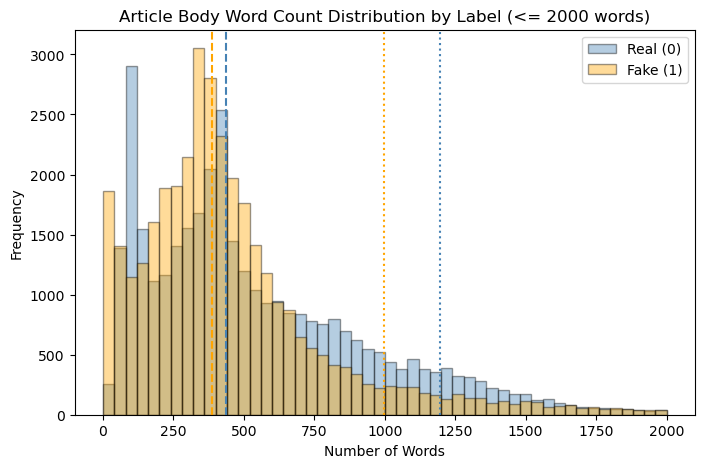

In [25]:
plt.figure(figsize=(8, 5))

for label, color, name in zip([0, 1], ['steelblue', 'orange'], ['Real (0)', 'Fake (1)']):
    subset = df_cleaned[df_cleaned['label'] == label]['word_count']
    
    plt.hist(
        subset,
        bins=50,
        range=(0, 2000),
        alpha=0.4,
        color=color,
        edgecolor='black',
        label=name
    )
    
    median_val = subset.median()
    p90_val = subset.quantile(0.90)
    
    plt.axvline(median_val, linestyle='dashed', linewidth=1.5, color=color)
    plt.axvline(p90_val, linestyle='dotted', linewidth=1.5, color=color)

plt.title('Article Body Word Count Distribution by Label (<= 2000 words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [18]:
df_cleaned[df_cleaned['label'] == 0]['title'].head(5)

3     Bobby Jindal, raised Hindu, uses story of Chri...
11    May Brexit offer would hurt, cost EU citizens ...
12    Schumer calls on Trump to appoint official to ...
14    No Change Expected for ESPN Political Agenda D...
15    Billionaire Odebrecht in Brazil scandal releas...
Name: title, dtype: object

In [19]:

df_cleaned[df_cleaned['label'] == 1]['title'].head(5)

0    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2    UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
4    SATAN 2: Russia unvelis an image of its terrif...
5    About Time! Christian Group Sues Amazon and SP...
6    DR BEN CARSON TARGETED BY THE IRS: “I never ha...
Name: title, dtype: object

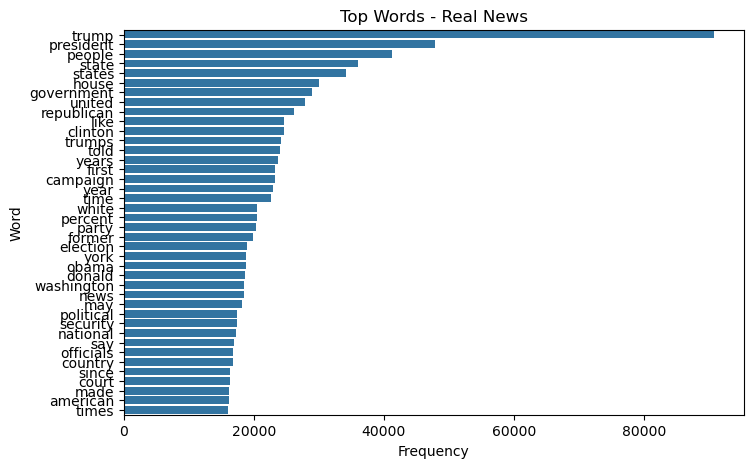

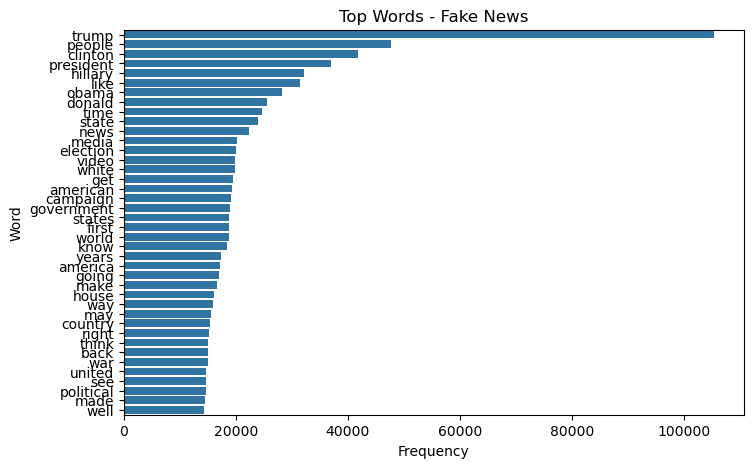

In [51]:
from collections import Counter
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
custom_stopwords = {
    'said', 'would', 'one', 'us', 'new', 'also', 'mr',
    'could', 'many', 'two', 'last', 'even', 'reuters'
}
all_stopwords = stop_words.union(custom_stopwords)

def preprocess_for_freq(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in all_stopwords and len(w) > 2]
    return tokens

def get_top_words(text_series, top_n=20):
    counter = Counter()
    for text in text_series:
        tokens = preprocess_for_freq(str(text))
        counter.update(tokens)
    return counter.most_common(top_n)

real_top = get_top_words(df_cleaned[df_cleaned['label'] == 0]['text'], top_n=40)
fake_top = get_top_words(df_cleaned[df_cleaned['label'] == 1]['text'], top_n=40)

def plot_top_words(word_list, title):
    words, counts = zip(*word_list)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()

plot_top_words(real_top, "Top Words - Real News")
plot_top_words(fake_top, "Top Words - Fake News")

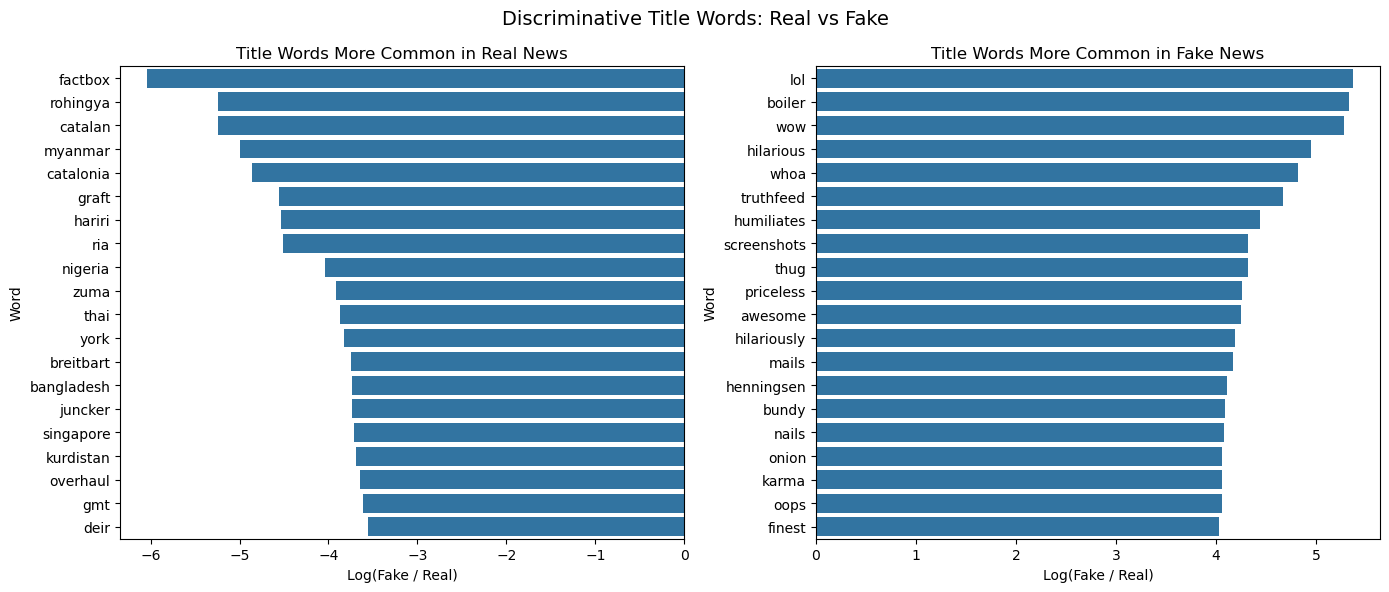

In [58]:
import re 
from collections import Counter
from nltk.corpus import stopwords 

label_map = {0: 'Real', 1: 'Fake'}
df_cleaned['label_name'] = df_cleaned['label'].map(label_map)

# --------------------------------------------------
# 2. Define stopwords
# --------------------------------------------------
stop_words = set(stopwords.words('english'))

custom_stopwords = {
    'said', 'would', 'one', 'us', 'new', 'also', 'mr',
    'could', 'many', 'two', 'last', 'even', 'reuters',
    'say', 'says'
}

# Optional domain-specific stopwords if they dominate too much
domain_stopwords = {
    'trump', 'clinton', 'obama', 'hillary', 'donald',
    'president', 'republican', 'democrat', 'trumps'
}

all_stopwords = stop_words.union(custom_stopwords).union(domain_stopwords)

# --------------------------------------------------
# 3. Text preprocessing function
# --------------------------------------------------
def preprocess_for_freq(text):
    text = str(text).lower()
    
    # remove URLs first
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # remove non-letters
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # tokenize
    tokens = text.split()
    
    # remove stopwords and very short tokens
    tokens = [w for w in tokens if w not in all_stopwords and len(w) > 2]
    
    return tokens

# --------------------------------------------------
# 4. Count words per class
# --------------------------------------------------
def get_word_counts(text_series):
    counter = Counter()
    for text in text_series:
        tokens = preprocess_for_freq(text)
        counter.update(tokens)
    return counter

# --------------------------------------------------
# 5. Compute discriminative log-ratio words
# --------------------------------------------------
def get_discriminative_words(real_series, fake_series, top_n=20, min_count=20):
    real_counts = get_word_counts(real_series)
    fake_counts = get_word_counts(fake_series)

    all_words = set(real_counts.keys()).union(set(fake_counts.keys()))
    word_scores = []

    for word in all_words:
        real = real_counts.get(word, 0)
        fake = fake_counts.get(word, 0)

        # remove rare words
        if real + fake < min_count:
            continue

        # log ratio with smoothing
        score = np.log((fake + 1) / (real + 1))
        word_scores.append((word, score, real, fake))

    # sort by score
    word_scores = sorted(word_scores, key=lambda x: x[1])

    # negative scores = more common in real
    top_real = word_scores[:top_n]

    # positive scores = more common in fake
    top_fake = word_scores[-top_n:][::-1]

    return top_real, top_fake, word_scores

# --------------------------------------------------
# 6. Plot function
# --------------------------------------------------
def plot_discriminative_words(top_real, top_fake, main_title,
                                     left_title="More Common in Real News",
                                     right_title="More Common in Fake News"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

    # left: real-biased words
    real_words = [x[0] for x in top_real]
    real_scores = [x[1] for x in top_real]

    sns.barplot(x=real_scores, y=real_words, ax=axes[0])
    axes[0].set_title(left_title)
    axes[0].set_xlabel("Log(Fake / Real)")
    axes[0].set_ylabel("Word")

    # right: fake-biased words
    fake_words = [x[0] for x in top_fake]
    fake_scores = [x[1] for x in top_fake]

    sns.barplot(x=fake_scores, y=fake_words, ax=axes[1])
    axes[1].set_title(right_title)
    axes[1].set_xlabel("Log(Fake / Real)")
    axes[1].set_ylabel("Word")

    fig.suptitle(main_title, fontsize=14)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# 7. TITLE analysis
# --------------------------------------------------
real_title = df_cleaned[df_cleaned['label'] == 0]['title']
fake_title = df_cleaned[df_cleaned['label'] == 1]['title']

top_real_title, top_fake_title, title_scores = get_discriminative_words(
    real_title,
    fake_title,
    top_n=20,
    min_count=20
)

plot_discriminative_words(
    top_real_title,
    top_fake_title,
    main_title="Discriminative Title Words: Real vs Fake",
    left_title="Title Words More Common in Real News",
    right_title="Title Words More Common in Fake News"
)


# CNN-LSTM Training + Analysis 

In this hybrid model, the CNN layer acts as a feature extractor that identifies local patterns (like specific phrases or tone) within the text. The output of the CNN is then fed into the LSTM layer, which captures the long-range dependencies and context across the entire article. 

fit_on_texts:

- tokenizes text (basic tokenization),
- lowercases by default,
- strips punctuation based on its internal filters,
- counts token frequencies,
- builds the vocabulary mapping.

texts_to_sequences:

- converts each token to its integer ID,
- produces a Python list of integers per document.
- This is not a vector embedding yet—just IDs.

In [5]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Parameters
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 400  # Number of words per article, P50 

# 1. Define y and indices FIRST
y = df_cleaned['label'].values
indices = np.arange(len(y))

# 2. First split: 80% Train+Val, 20% Test
train_val_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)

# 3. Second split: Split 80% into 70% Train and 10% Val (test_size=0.125 of 80% ≈ 10%)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.125, random_state=42, stratify=y[train_val_idx]
)

# 4. Initialize Tokenizer and fit ONLY on training texts to prevent data leakage
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df_cleaned['text'].iloc[train_idx]) 

# 5. Convert text to sequences of integers (applies to all data using the train-fitted tokenizer)
sequences = tokenizer.texts_to_sequences(df_cleaned['text'])

# 6. Pad/Truncate sequences
# Padding 'post' means zeros are added to the end of shorter texts
X_dl = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# 7. Create padded sequences for PyTorch sequence models
X_train_seq = X_dl[train_idx]
X_val_seq = X_dl[val_idx]
X_test_seq = X_dl[test_idx]
y_train_seq = y[train_idx]
y_val_seq = y[val_idx]
y_test_seq = y[test_idx]

# 8. Raw text for transformer (TokenizedTextDataset tokenizes on-the-fly)
X_train_text = df_cleaned['text'].iloc[train_idx].values
X_val_text = df_cleaned['text'].iloc[val_idx].values
X_test_text = df_cleaned['text'].iloc[test_idx].values

print(f"Shape of Data Tensor: {X_dl.shape}")
print(f"Train: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")

Shape of Data Tensor: (71537, 400)
Train: (50075, 400) | Val: (7154, 400) | Test: (14308, 400)


In [6]:
import torch
from torch.utils.data import DataLoader, Dataset 
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

class FakeNewsDataset(Dataset):
    def __init__(self, sequences, labels):
        # Ensure data is in tensor format
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.FloatTensor(labels)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Create datasets and loaders (uses X_train_seq, X_val_seq, X_test_seq from tokenizer cell)
batch_size = 64
train_dataset = FakeNewsDataset(X_train_seq, y_train_seq)
val_dataset = FakeNewsDataset(X_val_seq, y_val_seq)
test_dataset = FakeNewsDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: mps


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_filters, filter_sizes, hidden_dim, output_dim, dropout,
                 pretrained_weights=None, freeze_embedding=False, use_layer_norm=False):
        super(CNNLSTMClassifier, self).__init__()
        
        # 1. Embedding Layer
        if pretrained_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_weights, freeze=freeze_embedding, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. CNN Layer
        self.conv = nn.Conv1d(in_channels=embedding_dim, 
                              out_channels=n_filters, 
                              kernel_size=filter_sizes)

        # 3. Layer Normalization (Applied to the n_filters dimension)
        self.use_layer_norm = use_layer_norm
        if use_layer_norm:
            self.ln = nn.LayerNorm(n_filters)
        
        # 4. LSTM Layer
        self.lstm = nn.LSTM(n_filters, 
                            hidden_dim, 
                            batch_first=True, 
                            bidirectional=True)
        
        # 5. Output layers
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, text):
        embedded = self.embedding(text) # [batch, len, emb]
        
        # Conv1d expects [batch, channels, length]
        conved = self.conv(embedded.permute(0, 2, 1)) # [batch, n_filters, reduced_len]
        
        # PERMUTE BEFORE NORM: [batch, reduced_len, n_filters]
        # This puts the feature dimension (100) at the end
        conved = conved.permute(0, 2, 1)
        
        if self.use_layer_norm:
            conved = self.ln(conved)
            
        conved = F.relu(conved)
        
        # LSTM handles [batch, length, channels] perfectly
        output, (hidden, cell) = self.lstm(conved)
        
        # Concatenate final forward and backward hidden states
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        
        return self.sigmoid(self.fc(hidden)).squeeze(-1)

In [8]:
# Initialize model
set_seed(42)
cnn_lstm_model = CNNLSTMClassifier(vocab_size=20000, embedding_dim=128, n_filters=100, 
                     filter_sizes=3, hidden_dim=64, output_dim=1, dropout=0.5).to(device)

# Loss Function: Ideal for binary labels
criterion = nn.BCELoss()

# Optimizer: Standard choice for DL
optimizer = torch.optim.Adam(cnn_lstm_model.parameters(), lr=0.001)
num_epochs = 3

In [9]:
def train(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)
        
        optimizer.zero_grad() # clear old gradients and compute new gradients each batch 
        predictions = model(sequences)
        
        loss = criterion(predictions, labels) # compute loss 
        loss.backward() # compute gradients 
        optimizer.step() # update weights 
        
        total_loss += loss.item() # accumulate loss 
    return total_loss / len(loader) # average loss over the dataset 

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def evaluate_metrics(model, loader, criterion, device):
    """Returns (avg_loss, metrics, labels, preds) for use in training loop and reporting."""
    model.eval() # set model to evaluation mode 
    all_probs = []
    all_labels = []
    total_loss = 0

    with torch.no_grad(): # disable gradient calculation; we are not training here and don't want to update weights 
        for sequences, labels in loader:
            sequences, labels = sequences.to(device), labels.to(device)
            probs = model(sequences)
            loss = criterion(probs, labels)
            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = [1 if p >= 0.5 else 0 for p in all_probs]
    avg_loss = total_loss / len(loader)
    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "auc": roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
    }
    return avg_loss, metrics, all_labels, all_preds

def report_final_metrics(model, loader, criterion, device):
    """Integrated performance report: Accuracy, Precision, Recall, AUC."""
    avg_loss, metrics, labels, preds = evaluate_metrics(model, loader, criterion, device)
    print("--- Final Model Evaluation ---")
    print(f"Loss:     {avg_loss:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"F1:       {metrics['f1']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:   {metrics['recall']:.4f}")
    print(f"AUC:      {metrics['auc']:.4f}")
    return metrics

import copy

def train_fixed_epochs(
    model, train_loader, val_loader, criterion, optimizer, device, n_epochs=3
):
    """Train for a fixed number of epochs."""
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    for epoch in range(n_epochs):
        train_loss = train(model, train_loader, criterion, optimizer)
        val_loss, val_metrics, _, _ = evaluate_metrics(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])

        print(f"  Epoch {epoch+1:02} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | Val F1: {val_metrics['f1']:.4f}")

    return model, history

def show_detailed_results(metrics, labels, preds):
    print("\n--- Model Performance ---")
    for name, value in metrics.items():
        print(f"{name.capitalize():10}: {value:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=['Real', 'Fake']))

    # Confusion Matrix as requested
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [11]:
import time
import pandas as pd

epoch_times = []
total_start = time.perf_counter()

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    train_loss = train(cnn_lstm_model, train_loader, criterion, optimizer)
    val_loss, val_metrics, val_labels, val_preds = evaluate_metrics(
        cnn_lstm_model, val_loader, criterion, device
    )

    epoch_time = time.perf_counter() - epoch_start
    epoch_times.append(epoch_time)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.3f} | "
        f"Val Loss: {val_loss:.3f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Time: {epoch_time:.2f} sec"
    )

total_time = time.perf_counter() - total_start

timing_df = pd.DataFrame({
    "epoch": list(range(1, num_epochs + 1)),
    "epoch_seconds": epoch_times
})

print(timing_df)
print(f"Average epoch time: {timing_df['epoch_seconds'].mean():.2f} sec")
print(f"Total training time: {total_time:.2f} sec")

Epoch 01 | Train Loss: 0.227 | Val Loss: 0.188 | Val F1: 0.9360 | Time: 38.93 sec
Epoch 02 | Train Loss: 0.093 | Val Loss: 0.066 | Val F1: 0.9774 | Time: 36.18 sec
Epoch 03 | Train Loss: 0.042 | Val Loss: 0.062 | Val F1: 0.9779 | Time: 35.15 sec
   epoch  epoch_seconds
0      1      38.929544
1      2      36.180035
2      3      35.147772
Average epoch time: 36.75 sec
Total training time: 110.26 sec


Epoch: 01
	Train Loss: 0.023 | Val Loss: 0.088 | Val F1: 0.9674
Epoch: 02
	Train Loss: 0.013 | Val Loss: 0.060 | Val F1: 0.9803
Epoch: 03
	Train Loss: 0.011 | Val Loss: 0.071 | Val F1: 0.9817
--- Final Model Evaluation (Test Set) ---
Loss:      0.0782
Accuracy:  0.9812
F1:        0.9817
Precision: 0.9759
Recall:    0.9875
AUC:       0.9976

--- Model Performance ---
Accuracy  : 0.9812
F1        : 0.9817
Precision : 0.9759
Recall    : 0.9875
Auc       : 0.9976

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.97      0.98      7006
        Fake       0.98      0.99      0.98      7302

    accuracy                           0.98     14308
   macro avg       0.98      0.98      0.98     14308
weighted avg       0.98      0.98      0.98     14308



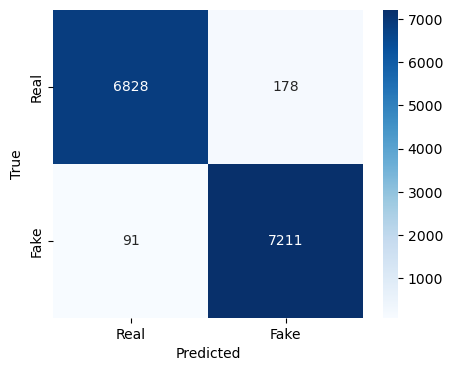

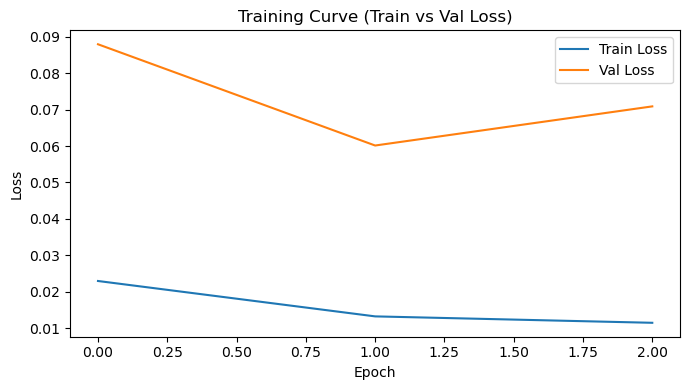

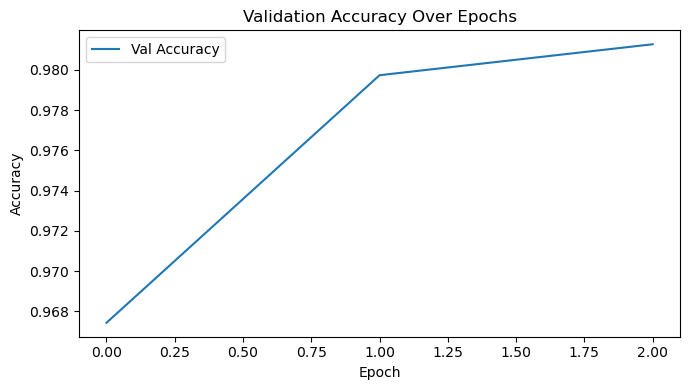

In [12]:
history_train_loss, history_val_loss, history_val_acc, history_val_f1 = [], [], [], []

for epoch in range(num_epochs):
    train_loss = train(cnn_lstm_model, train_loader, criterion, optimizer)
    val_loss, val_metrics, val_labels, val_preds = evaluate_metrics(
        cnn_lstm_model, val_loader, criterion, device
    )

    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    history_val_acc.append(val_metrics["accuracy"])
    history_val_f1.append(val_metrics["f1"])

    print(f"Epoch: {epoch+1:02}")
    print(f"\tTrain Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | Val F1: {val_metrics['f1']:.4f}")

# Final evaluation on test set
test_loss, test_metrics, test_labels, test_preds = evaluate_metrics(cnn_lstm_model, test_loader, criterion, device)
print("--- Final Model Evaluation (Test Set) ---")
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"AUC:       {test_metrics['auc']:.4f}")
show_detailed_results(test_metrics, test_labels, test_preds)

# Plot training curves
plt.figure(figsize=(7, 4))
plt.plot(history_train_loss, label="Train Loss")
plt.plot(history_val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve (Train vs Val Loss)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Mislabeled News Analysis 

In [13]:
false_pos_idx = [i for i in range(len(test_labels))
                 if test_labels[i] == 0 and test_preds[i] == 1]

false_neg_idx = [i for i in range(len(test_labels))
                 if test_labels[i] == 1 and test_preds[i] == 0]

df_cleaned.iloc[test_idx[false_pos_idx]]['text'] # predicted fake but actually real 


17868    Chaos on House floor as Dems, Republicans clas...
8881     Mexican Leaders Caught Lying Again in Cartel E...
56829    Chinese Companies Are Investing American Manuf...
49025    Ladies and Gentlemen, Mr. Broadway – Nathan La...
67275    Donald Trump’s white fascist brigade: His rall...
                               ...                        
13615    America is criminalizing Black teachers: Atlan...
30441    One of this election's bright spots: early vot...
50463    The Oregon standoff and America’s double stand...
15445    UN Gay Rights Envoy: Religious Freedom ‘Not an...
63706    Scientists Turn Spinach Leaf into Beating Huma...
Name: text, Length: 178, dtype: object

In [14]:
# df_cleaned.iloc[test_idx[false_pos_idx]][['text', 'label']].to_csv('false_positives.csv', index=False)
# df_cleaned.iloc[test_idx[false_neg_idx]][['text', 'label']].to_csv('false_negatives.csv', index=False)

In [15]:
# # Error-analysis lexical comparison (no wordcloud)
# # Produces:
# # 1) Top-N frequent words for False Positives vs False Negatives
# # 2) Top-N TF-IDF "distinctive" words for False Positives vs False Negatives
# # 3) Optional: same analysis for Correct Real vs Correct Fake (for contrast)

# import re
# import numpy as np
# import pandas as pd
# from collections import Counter

# from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Uses X_test_text, y_test_seq, test_preds from training cell (cell 13)
# REAL_LABEL = 0
# FAKE_LABEL = 1

# # Simple tokenizer
# STOPWORDS = set(ENGLISH_STOP_WORDS)

# def tokenize(text: str):
#     tokens = re.findall(r"[a-zA-Z]+", text.lower())
#     tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
#     return tokens

# # Build groups of indices
# y_test_arr = np.array(y_test_seq)
# y_pred_arr = np.array(test_preds)

# false_pos_idx = np.where((y_test_arr == REAL_LABEL) & (y_pred_arr == FAKE_LABEL))[0]  # Real -> Fake
# false_neg_idx = np.where((y_test_arr == FAKE_LABEL) & (y_pred_arr == REAL_LABEL))[0]  # Fake -> Real

# correct_real_idx = np.where((y_test_arr == REAL_LABEL) & (y_pred_arr == REAL_LABEL))[0]
# correct_fake_idx = np.where((y_test_arr == FAKE_LABEL) & (y_pred_arr == FAKE_LABEL))[0]

# def subset_text(idxs):
#     return [X_test_text[i] for i in idxs]

# fp_texts = subset_text(false_pos_idx)
# fn_texts = subset_text(false_neg_idx)
# cr_texts = subset_text(correct_real_idx)
# cf_texts = subset_text(correct_fake_idx)

# print("Counts:")
# print("False Positives (Real->Fake):", len(fp_texts))
# print("False Negatives (Fake->Real):", len(fn_texts))
# print("Correct Real:", len(cr_texts))
# print("Correct Fake:", len(cf_texts))

# # 1) Top-N frequent words
# def top_words_frequency(texts, top_n=10):
#     counter = Counter()
#     for txt in texts:
#         counter.update(tokenize(txt))
#     return counter.most_common(top_n)

# TOP_N = 10
# fp_top_freq = top_words_frequency(fp_texts, TOP_N)
# fn_top_freq = top_words_frequency(fn_texts, TOP_N)

# freq_df = pd.DataFrame({
#     "False Positives - Top Words": [w for w, _ in fp_top_freq],
#     "FP Count": [c for _, c in fp_top_freq],
#     "False Negatives - Top Words": [w for w, _ in fn_top_freq],
#     "FN Count": [c for _, c in fn_top_freq],
# })

# print("\nTop frequent words (misclassified):")
# print(freq_df)

# # 2) TF-IDF distinctive words (FP vs FN)
# vectorizer = TfidfVectorizer(
#     lowercase=True,
#     stop_words="english",
#     token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
#     max_features=20000
# )

# docs = fp_texts + fn_texts
# labels = np.array([1] * len(fp_texts) + [0] * len(fn_texts))

# if len(docs) >= 2 and len(fp_texts) > 0 and len(fn_texts) > 0:
#     X = vectorizer.fit_transform(docs)
#     feature_names = np.array(vectorizer.get_feature_names_out())

#     fp_mean = X[labels == 1].mean(axis=0).A1
#     fn_mean = X[labels == 0].mean(axis=0).A1

#     diff_fp = fp_mean - fn_mean
#     diff_fn = fn_mean - fp_mean

#     fp_top_idx = np.argsort(diff_fp)[::-1][:TOP_N]
#     fn_top_idx = np.argsort(diff_fn)[::-1][:TOP_N]

#     tfidf_df = pd.DataFrame({
#         "FP Distinctive (TF-IDF)": feature_names[fp_top_idx],
#         "FP Mean TF-IDF": fp_mean[fp_top_idx].round(4),
#         "FN Distinctive (TF-IDF)": feature_names[fn_top_idx],
#         "FN Mean TF-IDF": fn_mean[fn_top_idx].round(4),
#     })

#     print("\nDistinctive TF-IDF words (FP vs FN):")
#     print(tfidf_df)
# else:
#     print("\nNot enough misclassified samples to compute TF-IDF distinctive words.")

# # 3) Contrast: Correct Fake vs Correct Real
# def distinctive_tfidf_groupA_vs_groupB(textsA, textsB, top_n=10, labelA="A", labelB="B"):
#     docs = textsA + textsB
#     labels = np.array([1] * len(textsA) + [0] * len(textsB))
#     if len(textsA) == 0 or len(textsB) == 0:
#         return None

#     vec = TfidfVectorizer(
#         lowercase=True, stop_words="english",
#         token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
#         max_features=20000
#     )
#     X = vec.fit_transform(docs)
#     feats = np.array(vec.get_feature_names_out())

#     a_mean = X[labels == 1].mean(axis=0).A1
#     b_mean = X[labels == 0].mean(axis=0).A1

#     diffA = a_mean - b_mean
#     diffB = b_mean - a_mean

#     a_idx = np.argsort(diffA)[::-1][:top_n]
#     b_idx = np.argsort(diffB)[::-1][:top_n]

#     return pd.DataFrame({
#         f"{labelA} Distinctive": feats[a_idx],
#         f"{labelA} Mean TF-IDF": a_mean[a_idx].round(4),
#         f"{labelB} Distinctive": feats[b_idx],
#         f"{labelB} Mean TF-IDF": b_mean[b_idx].round(4),
#     })

# contrast_df = distinctive_tfidf_groupA_vs_groupB(cf_texts, cr_texts, top_n=TOP_N,
#                                                 labelA="Correct Fake", labelB="Correct Real")
# if contrast_df is not None:
#     print("\nDistinctive TF-IDF words (Correct Fake vs Correct Real):")
#     print(contrast_df)

## Topic Modeling (LDA): Error Analysis by Topic

Fit LDA on the full cleaned dataset to discover latent topics, then trace which topics have the highest misclassification rates.

In [16]:
# from sklearn.decomposition import LatentDirichletAllocation
# from sklearn.feature_extraction.text import CountVectorizer

# N_TOPICS = 6
# TOP_N_WORDS = 10

# # 1. Fit LDA on full cleaned dataset
# count_vec = CountVectorizer(
#     lowercase=True, stop_words="english",
#     token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
#     max_features=10000
# )
# X_counts_all = count_vec.fit_transform(df_cleaned['text'])
# terms = count_vec.get_feature_names_out()

# lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42)
# lda.fit(X_counts_all)

# print("=== LDA Topics (fit on full dataset) ===")
# for idx, topic in enumerate(lda.components_):
#     top_words = [terms[i] for i in topic.argsort()[::-1][:TOP_N_WORDS]]
#     print(f"  Topic {idx}: {', '.join(top_words)}")

# # 2. Assign dominant topic to each test document
# X_counts_test = count_vec.transform(X_test_text)
# topic_dist_test = lda.transform(X_counts_test)
# test_topics = topic_dist_test.argmax(axis=1)

# # 3. Build DataFrame: true label, predicted label, dominant topic
# y_test_arr = np.array(y_test_seq)
# y_pred_arr = np.array(test_preds)

# error_df = pd.DataFrame({
#     "true_label": y_test_arr,
#     "pred_label": y_pred_arr,
#     "topic": test_topics,
#     "correct": (y_test_arr == y_pred_arr).astype(int),
# })

# # 4. Error rate by topic
# topic_summary = error_df.groupby("topic").agg(
#     total=("correct", "count"),
#     correct=("correct", "sum"),
# ).reset_index()
# topic_summary["errors"] = topic_summary["total"] - topic_summary["correct"]
# topic_summary["error_rate"] = (topic_summary["errors"] / topic_summary["total"]).round(4)
# topic_summary["accuracy"] = (topic_summary["correct"] / topic_summary["total"]).round(4)

# # Add top words for readability
# topic_summary["top_words"] = topic_summary["topic"].apply(
#     lambda t: ", ".join([terms[i] for i in lda.components_[t].argsort()[::-1][:5]])
# )

# print("\n=== Error Rate by Topic ===")
# print(topic_summary[["topic", "top_words", "total", "errors", "error_rate", "accuracy"]].to_string(index=False))

# # 5. Break down FP and FN by topic
# error_df["error_type"] = "Correct"
# error_df.loc[(y_test_arr == 0) & (y_pred_arr == 1), "error_type"] = "FP (Real->Fake)"
# error_df.loc[(y_test_arr == 1) & (y_pred_arr == 0), "error_type"] = "FN (Fake->Real)"

# error_breakdown = error_df[error_df["error_type"] != "Correct"].groupby(
#     ["topic", "error_type"]).size().unstack(fill_value=0)
# print("\n=== FP/FN Counts by Topic ===")
# print(error_breakdown)

# # 6. Plot error rate by topic
# fig, ax = plt.subplots(figsize=(8, 4))
# bars = ax.bar(topic_summary["topic"], topic_summary["error_rate"], color="salmon")
# ax.set_xlabel("Topic")
# ax.set_ylabel("Error Rate")
# ax.set_title("Misclassification Rate by LDA Topic")
# ax.set_xticks(range(N_TOPICS))
# ax.set_xticklabels([f"Topic {t}" for t in range(N_TOPICS)], rotation=45, ha="right")
# for bar, rate in zip(bars, topic_summary["error_rate"]):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
#             f"{rate:.1%}", ha="center", va="bottom", fontsize=9)
# plt.tight_layout()
# plt.show()

## Structural Error Analysis: NER Profile + Narrative Style

Compare True Real, True Fake, False Positive (Real->Fake), and False Negative (Fake->Real) across named entity profiles and structural writing features.

In [17]:
import spacy
import re
from textblob import TextBlob
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer"])
nlp.add_pipe("sentencizer")
nlp.max_length = 2_000_000

# --- 1. Build 4 groups from test set ---
y_test_arr = np.array(y_test_seq)
y_pred_arr = np.array(test_preds)

groups = {
    "True Real (TR)":       np.where((y_test_arr == 0) & (y_pred_arr == 0))[0],
    "True Fake (TF)":       np.where((y_test_arr == 1) & (y_pred_arr == 1))[0],
    "False Positive (FP)":  np.where((y_test_arr == 0) & (y_pred_arr == 1))[0],
    "False Negative (FN)":  np.where((y_test_arr == 1) & (y_pred_arr == 0))[0],
}

for name, idxs in groups.items():
    print(f"{name}: {len(idxs)} documents")

# Sample to keep runtime reasonable (all FP/FN, sample from TR/TF)
MAX_SAMPLE = 500
np.random.seed(42)

sampled_groups = {}
for name, idxs in groups.items():
    if len(idxs) > MAX_SAMPLE and name.startswith("True"):
        sampled_groups[name] = np.random.choice(idxs, MAX_SAMPLE, replace=False)
    else:
        sampled_groups[name] = idxs

print("\nSampled sizes:")
for name, idxs in sampled_groups.items():
    print(f"  {name}: {len(idxs)}")

# --- 2. Feature extraction (batched with nlp.pipe) ---
# All features derived from the same truncated window (first 10k chars) for consistency.

def extract_features_batch(texts):
    """Batch-extract NER + structural features using nlp.pipe."""
    truncated = [t[:10000] for t in texts]
    results = []
    
    for doc, text_used in zip(nlp.pipe(truncated, batch_size=64), truncated):
        # NER counts
        ner_counts = Counter(ent.label_ for ent in doc.ents)
        n_person = ner_counts.get("PERSON", 0)
        n_org = ner_counts.get("ORG", 0)
        n_gpe = ner_counts.get("GPE", 0)
        n_norp = ner_counts.get("NORP", 0)
        n_total_ents = len(doc.ents)

        # Sentence segmentation via spaCy sentencizer
        sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 5]
        n_sentences = max(len(sentences), 1)
        avg_sent_len = np.mean([len(s.split()) for s in sentences]) if sentences else 0

        # Word/token features from the same truncated text
        words = text_used.split()
        n_words = max(len(words), 1)
        ent_density_sent = n_total_ents / n_sentences
        ent_per_100_tokens = 100 * n_total_ents / n_words

        # NORP ratio (group-identity emphasis)
        norp_ratio = n_norp / max(n_total_ents, 1)

        # Structural style
        caps_ratio = sum(1 for w in words if w.isupper() and len(w) > 1) / n_words
        exclamation_count = text_used.count("!")
        question_count = text_used.count("?")
        quote_count = text_used.count('"') + text_used.count('\u201c') + text_used.count('\u201d')
        quote_density = quote_count / n_words

        # Lexical diversity: TTR on fixed 300-token window
        tokens_lower = [w.lower() for w in re.findall(r"[A-Za-z]+", text_used)]
        window = tokens_lower[:300] if len(tokens_lower) >= 300 else tokens_lower
        ttr_300 = len(set(window)) / max(len(window), 1)
        avg_word_len = np.mean([len(w) for w in tokens_lower]) if tokens_lower else 0

        # Sentiment (TextBlob)
        blob = TextBlob(text_used[:5000])
        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity

        # High-polarity sentence ratio
        if sentences:
            polarities = [TextBlob(s).sentiment.polarity for s in sentences[:50]]
            high_polar_ratio = sum(1 for p in polarities if abs(p) > 0.5) / len(polarities)
        else:
            high_polar_ratio = 0

        results.append({
            "n_words": n_words,
            "n_sentences": n_sentences,
            "avg_sent_len": avg_sent_len,
            "PERSON": n_person,
            "ORG": n_org,
            "GPE": n_gpe,
            "NORP": n_norp,
            "total_entities": n_total_ents,
            "ent_density_per_sent": ent_density_sent,
            "ent_per_100_tokens": ent_per_100_tokens,
            "norp_ratio": norp_ratio,
            "caps_ratio": caps_ratio,
            "exclamation_count": exclamation_count,
            "question_count": question_count,
            "quote_density": quote_density,
            "ttr_300": ttr_300,
            "avg_word_len": avg_word_len,
            "polarity": polarity,
            "subjectivity": subjectivity,
            "high_polar_ratio": high_polar_ratio,
        })
    return results

# --- 3. Run extraction per group (batched) ---
all_features = []
for group_name, idxs in sampled_groups.items():
    print(f"\nExtracting features for {group_name} ({len(idxs)} docs)...")
    texts = [X_test_text[i] for i in idxs]
    feats_list = extract_features_batch(texts)
    for f in feats_list:
        f["group"] = group_name
    all_features.extend(feats_list)

features_df = pd.DataFrame(all_features)
print(f"\nTotal feature rows: {len(features_df)}")


True Real (TR): 6828 documents
True Fake (TF): 7211 documents
False Positive (FP): 178 documents
False Negative (FN): 91 documents

Sampled sizes:
  True Real (TR): 500
  True Fake (TF): 500
  False Positive (FP): 178
  False Negative (FN): 91

Extracting features for True Real (TR) (500 docs)...

Extracting features for True Fake (TF) (500 docs)...

Extracting features for False Positive (FP) (178 docs)...

Extracting features for False Negative (FN) (91 docs)...

Total feature rows: 1269


=== Structural Feature Comparison (group means) ===
group                 True Real (TR)  False Positive (FP)  False Negative (FN)  True Fake (TF)
n_words                     544.2420             650.9831             657.4286        481.9980
n_sentences                  24.4380              31.3708              30.9670         22.4340
avg_sent_len                 23.7819              21.4108              21.9332         21.9854
PERSON                       13.9420              16.1517              14.9560         13.5060
ORG                          12.2700              13.6798              12.5385         10.8580
GPE                          11.0360               8.1517               8.0000          6.7760
NORP                          5.9620               5.9551               5.6374          4.0500
total_entities               60.7720              62.8989              58.8571         47.6260
ent_density_per_sent          3.0534               2.2055               2.2238          2.297

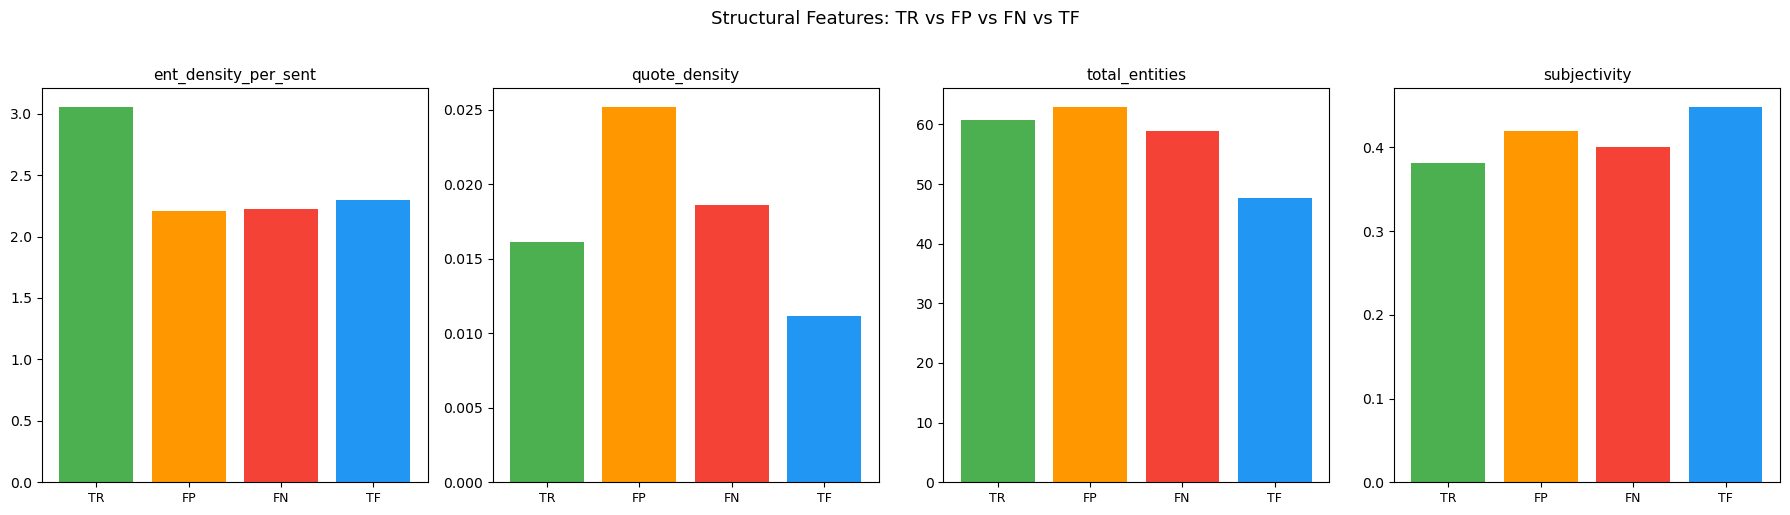

In [18]:
# --- 4. Summary table: mean features per group ---
feature_cols = [c for c in features_df.columns if c != "group"]
summary = features_df.groupby("group")[feature_cols].mean().T
summary = summary[["True Real (TR)", "False Positive (FP)", "False Negative (FN)", "True Fake (TF)"]]
summary = summary.round(4)

print("=== Structural Feature Comparison (group means) ===")
print(summary.to_string())

# --- 5. Key insight: FP vs TR (what makes real look fake?) ---
print("\n\n=== FP vs TR: What makes Real articles look Fake? ===")
fp_vs_tr = pd.DataFrame({
    "True Real (TR)": summary["True Real (TR)"],
    "False Positive (FP)": summary["False Positive (FP)"],
    "Diff (FP - TR)": (summary["False Positive (FP)"] - summary["True Real (TR)"]).round(4),
})
fp_vs_tr["abs_diff"] = fp_vs_tr["Diff (FP - TR)"].abs()
fp_vs_tr = fp_vs_tr.sort_values("abs_diff", ascending=False)
print(fp_vs_tr.drop(columns="abs_diff").head(10).to_string())

# --- 6. Key insight: FN vs TF (what makes Fake articles look Real?) ---
print("\n\n=== FN vs TF: What makes Fake articles look Real? ===")
fn_vs_tf = pd.DataFrame({
    "True Fake (TF)": summary["True Fake (TF)"],
    "False Negative (FN)": summary["False Negative (FN)"],
    "Diff (FN - TF)": (summary["False Negative (FN)"] - summary["True Fake (TF)"]).round(4),
})
fn_vs_tf["abs_diff"] = fn_vs_tf["Diff (FN - TF)"].abs()
fn_vs_tf = fn_vs_tf.sort_values("abs_diff", ascending=False)
print(fn_vs_tf.drop(columns="abs_diff").head(10).to_string())

# --- 7. Visualization: grouped bar chart for key features ---
key_features = ["ent_density_per_sent", "quote_density", "total_entities", "subjectivity"]

plot_data = features_df.groupby("group")[key_features].mean()
plot_data = plot_data.loc[["True Real (TR)", "False Positive (FP)", "False Negative (FN)", "True Fake (TF)"]]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = {"True Real (TR)": "#4CAF50", "False Positive (FP)": "#FF9800",
          "False Negative (FN)": "#F44336", "True Fake (TF)": "#2196F3"}

for ax, feat in zip(axes, key_features):
    vals = plot_data[feat]
    ax.bar(range(4), vals, color=[colors[g] for g in plot_data.index])
    ax.set_title(feat, fontsize=11)
    ax.set_xticks(range(4))
    ax.set_xticklabels(["TR", "FP", "FN", "TF"], fontsize=9)

fig.suptitle("Structural Features: TR vs FP vs FN vs TF", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
group_dfs = {}
for name, idxs in groups.items():
    group_dfs[name] = df_cleaned.iloc[test_idx[idxs]].copy()

# Sampled group DataFrames (the 500-sample versions used for feature extraction)
sampled_dfs = {}
for name, idxs in sampled_groups.items():
    sampled_dfs[name] = df_cleaned.iloc[test_idx[idxs]].copy()

# Example: view False Positives
# pd.set_option('display.max_colwidth', None)
sampled_dfs["True Real (TR)"].to_csv("true_real_sampled.csv", index=False)
sampled_dfs["True Fake (TF)"].to_csv("true_fake_sampled.csv", index=False) 

In [20]:
cnn_lstm_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_seqs, labels in test_loader:
        batch_seqs = batch_seqs.to(device)
        probs = cnn_lstm_model(batch_seqs).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

# Build a DataFrame with probabilities
prob_df = pd.DataFrame({
    "true_label": all_labels,
    "pred_label": all_preds,
    "pred_prob": all_probs,
})

# Tag each row
prob_df["group"] = "Other"
prob_df.loc[(prob_df.true_label == 0) & (prob_df.pred_label == 0), "group"] = "True Real (TR)"
prob_df.loc[(prob_df.true_label == 1) & (prob_df.pred_label == 1), "group"] = "True Fake (TF)"
prob_df.loc[(prob_df.true_label == 0) & (prob_df.pred_label == 1), "group"] = "False Positive (FP)"
prob_df.loc[(prob_df.true_label == 1) & (prob_df.pred_label == 0), "group"] = "False Negative (FN)"

# See the distribution
print(prob_df.groupby("group")["pred_prob"].describe().round(4))

                      count    mean     std     min     25%     50%     75%  \
group                                                                         
False Negative (FN)    91.0  0.1354  0.1506  0.0001  0.0157  0.0604  0.2073   
False Positive (FP)   178.0  0.9143  0.1280  0.5229  0.8874  0.9805  0.9983   
True Fake (TF)       7211.0  0.9974  0.0235  0.5170  0.9998  0.9999  1.0000   
True Real (TR)       6828.0  0.0046  0.0312  0.0000  0.0000  0.0001  0.0003   

                        max  
group                        
False Negative (FN)  0.4832  
False Positive (FP)  1.0000  
True Fake (TF)       1.0000  
True Real (TR)       0.4765  


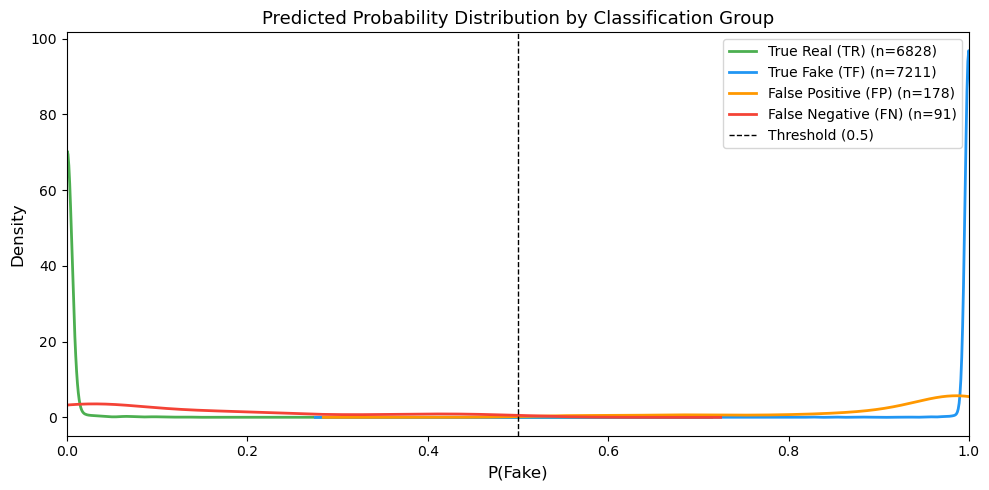

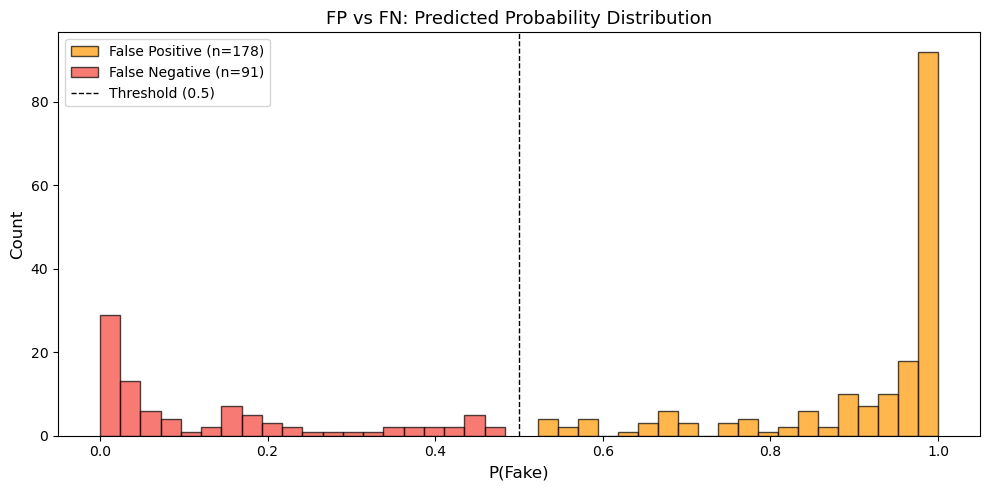

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {
    "True Real (TR)": "#4CAF50",
    "True Fake (TF)": "#2196F3",
    "False Positive (FP)": "#FF9800",
    "False Negative (FN)": "#F44336",
}

for group, color in colors.items():
    subset = prob_df[prob_df.group == group]["pred_prob"]
    if len(subset) > 1:
        subset.plot.kde(ax=ax, label=f"{group} (n={len(subset)})", color=color, linewidth=2)

ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Threshold (0.5)")
ax.set_xlim(0, 1)
ax.set_xlabel("P(Fake)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Predicted Probability Distribution by Classification Group", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

fp = prob_df[prob_df.group == "False Positive (FP)"]["pred_prob"]
fn = prob_df[prob_df.group == "False Negative (FN)"]["pred_prob"]

ax.hist(fp, bins=20, color="#FF9800", edgecolor="black", alpha=0.7, label=f"False Positive (n={len(fp)})")
ax.hist(fn, bins=20, color="#F44336", edgecolor="black", alpha=0.7, label=f"False Negative (n={len(fn)})")

ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Threshold (0.5)")
ax.set_xlabel("P(Fake)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("FP vs FN: Predicted Probability Distribution", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Ablation Studies

### Ablation 1: Data Preprocessing (Sequence Length)
Compare accuracy when MAX_SEQUENCE_LENGTH = 100 vs 300 vs 500.

In [22]:
# Ablation 1: Sequence Length
ablation1_results = []
ablation1_models = {}

for max_len in [100, 400, 700, 1100]:
    print(f"\n--- max_len={max_len} ---")
    X_dl_ab = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    X_tr = X_dl_ab[train_idx]; X_val = X_dl_ab[val_idx]; X_te = X_dl_ab[test_idx]

    ld_tr = DataLoader(FakeNewsDataset(X_tr, y_train_seq), batch_size=64, shuffle=True)
    ld_val = DataLoader(FakeNewsDataset(X_val, y_val_seq), batch_size=64)

    set_seed(42)
    m = CNNLSTMClassifier(
        vocab_size=MAX_VOCAB_SIZE, embedding_dim=128, n_filters=100,
        filter_sizes=3, hidden_dim=64, output_dim=1, dropout=0.5
    ).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.001)

    m, hist = train_fixed_epochs(m, ld_tr, ld_val, criterion, opt, device, n_epochs=3)

    _, val_metrics, _, _ = evaluate_metrics(m, ld_val, criterion, device)
    ablation1_results.append({
        "max_len": max_len, "val_f1": val_metrics["f1"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"], "val_recall": val_metrics["recall"],
        "val_auc": val_metrics["auc"],
    })
    ablation1_models[max_len] = m

# Select winner by validation F1
ablation1_df = pd.DataFrame(ablation1_results).sort_values("val_f1", ascending=False)
print("\n--- Ablation 1 Validation Summary ---")
print(ablation1_df.to_string(index=False))
best_len = int(ablation1_df.iloc[0]["max_len"])
print(f"\nBest max_len by validation F1: {best_len}")

# Final test eval for winner only
X_best = pad_sequences(sequences, maxlen=best_len, padding='post', truncating='post')
ld_te_best = DataLoader(FakeNewsDataset(X_best[test_idx], y_test_seq), batch_size=64)
_, test_metrics, _, _ = evaluate_metrics(ablation1_models[best_len], ld_te_best, criterion, device)
print(f"\n--- Final Test Metrics (max_len={best_len}) ---")
for k, v in test_metrics.items():
    print(f"  {k.capitalize()}: {v:.4f}")


--- max_len=100 ---
  Epoch 01 | Train Loss: 0.227 | Val Loss: 0.132 | Val F1: 0.9515
  Epoch 02 | Train Loss: 0.091 | Val Loss: 0.099 | Val F1: 0.9640
  Epoch 03 | Train Loss: 0.051 | Val Loss: 0.110 | Val F1: 0.9649

--- max_len=400 ---
  Epoch 01 | Train Loss: 0.227 | Val Loss: 0.127 | Val F1: 0.9499
  Epoch 02 | Train Loss: 0.079 | Val Loss: 0.062 | Val F1: 0.9791
  Epoch 03 | Train Loss: 0.033 | Val Loss: 0.064 | Val F1: 0.9811

--- max_len=700 ---
  Epoch 01 | Train Loss: 0.231 | Val Loss: 0.129 | Val F1: 0.9528
  Epoch 02 | Train Loss: 0.084 | Val Loss: 0.071 | Val F1: 0.9777
  Epoch 03 | Train Loss: 0.035 | Val Loss: 0.047 | Val F1: 0.9826

--- max_len=1100 ---
  Epoch 01 | Train Loss: 0.225 | Val Loss: 0.132 | Val F1: 0.9484
  Epoch 02 | Train Loss: 0.153 | Val Loss: 0.119 | Val F1: 0.9528
  Epoch 03 | Train Loss: 0.065 | Val Loss: 0.059 | Val F1: 0.9788

--- Ablation 1 Validation Summary ---
 max_len   val_f1  val_accuracy  val_precision  val_recall  val_auc
     700 0.98262

### Ablation 2: Regularization (Dropout)
Compare dropout=0.0 vs dropout=0.5. High dropout should reduce the gap between train and val loss.


--- Baseline (Dropout=0.0, LN=No) ---
  Epoch 01 | Train Loss: 0.200 | Val Loss: 0.099 | Val F1: 0.9631
  Epoch 02 | Train Loss: 0.061 | Val Loss: 0.063 | Val F1: 0.9778
  Epoch 03 | Train Loss: 0.027 | Val Loss: 0.053 | Val F1: 0.9831

--- Dropout Only (0.5, LN=No) ---
  Epoch 01 | Train Loss: 0.227 | Val Loss: 0.184 | Val F1: 0.9318
  Epoch 02 | Train Loss: 0.088 | Val Loss: 0.067 | Val F1: 0.9767
  Epoch 03 | Train Loss: 0.039 | Val Loss: 0.060 | Val F1: 0.9819

--- LayerNorm Only (Dropout=0.0, LN=Yes) ---
  Epoch 01 | Train Loss: 0.189 | Val Loss: 0.092 | Val F1: 0.9673
  Epoch 02 | Train Loss: 0.055 | Val Loss: 0.055 | Val F1: 0.9793
  Epoch 03 | Train Loss: 0.024 | Val Loss: 0.056 | Val F1: 0.9804

--- Dropout (0.5) + LayerNorm (LN=Yes) ---
  Epoch 01 | Train Loss: 0.223 | Val Loss: 0.124 | Val F1: 0.9502
  Epoch 02 | Train Loss: 0.070 | Val Loss: 0.057 | Val F1: 0.9788
  Epoch 03 | Train Loss: 0.031 | Val Loss: 0.063 | Val F1: 0.9808


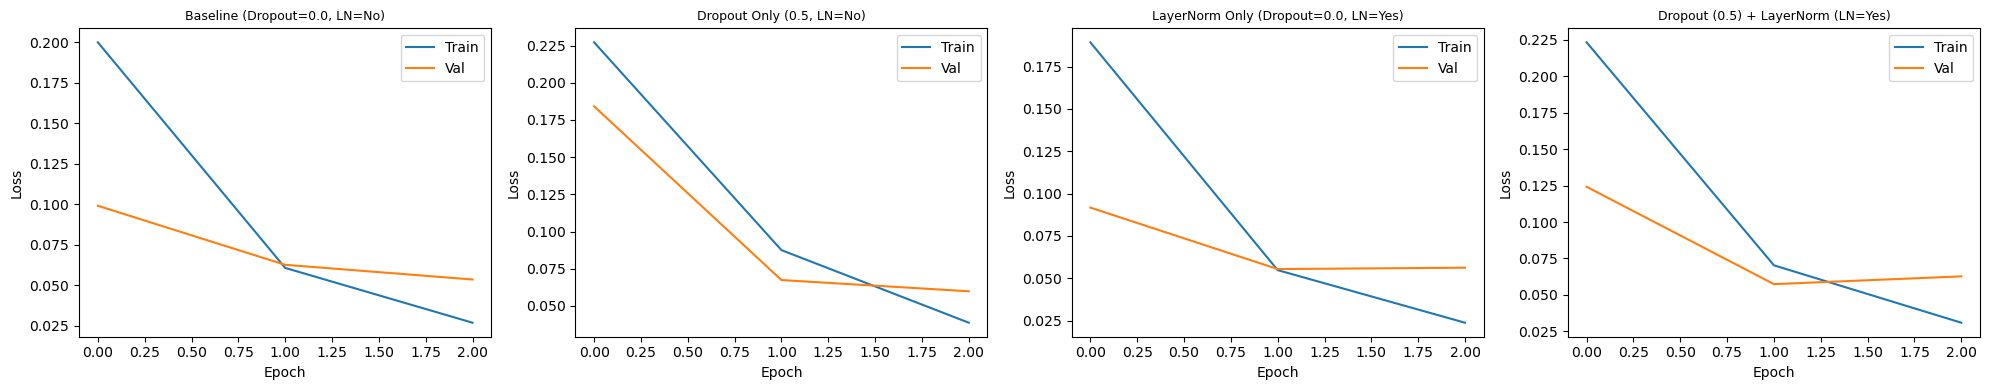


--- Ablation 2 Validation Metrics ---
                       Configuration       F1  Accuracy  Precision   Recall  AUC Score
       Baseline (Dropout=0.0, LN=No) 0.983148  0.982807   0.983553 0.982744   0.998256
           Dropout Only (0.5, LN=No) 0.981907  0.981409   0.975405 0.988496   0.997982
  Dropout (0.5) + LayerNorm (LN=Yes) 0.980777  0.980291   0.976384 0.985210   0.998089
LayerNorm Only (Dropout=0.0, LN=Yes) 0.980355  0.979871   0.976624 0.984114   0.998005

Evaluating winner (Baseline (Dropout=0.0, LN=No)) on TEST set...
--- Final Test Metrics (Ablation 2 Winner) ---
  Accuracy: 0.9808
  F1: 0.9813
  Precision: 0.9793
  Recall: 0.9833
  Auc: 0.9977


In [23]:
# Ablation 2: Regularization (Dropout + LayerNorm)
ablation2_configs = [
    ("Baseline (Dropout=0.0, LN=No)",         0.0, False),
    ("Dropout Only (0.5, LN=No)",             0.5, False),
    ("LayerNorm Only (Dropout=0.0, LN=Yes)",  0.0, True),
    ("Dropout (0.5) + LayerNorm (LN=Yes)",    0.5, True),
]

ablation2_models = {}
ablation2_histories = {}
ablation2_results = []

for name, drop, ln in ablation2_configs:
    print(f"\n--- {name} ---")
    set_seed(42)
    m = CNNLSTMClassifier(
        vocab_size=MAX_VOCAB_SIZE, embedding_dim=128, n_filters=100,
        filter_sizes=3, hidden_dim=64, output_dim=1, dropout=drop, use_layer_norm=ln
    ).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.001)

    m, hist = train_fixed_epochs(m, train_loader, val_loader, criterion, opt, device, n_epochs=3)
    _, val_metrics, _, _ = evaluate_metrics(m, val_loader, criterion, device)
    ablation2_models[name] = m
    ablation2_histories[name] = hist
    ablation2_results.append({
        "Configuration": name, "F1": val_metrics["f1"],
        "Accuracy": val_metrics["accuracy"],
        "Precision": val_metrics["precision"], "Recall": val_metrics["recall"],
        "AUC Score": val_metrics["auc"],
    })

# Plot train vs val loss curves
fig, axes = plt.subplots(1, len(ablation2_configs), figsize=(5 * len(ablation2_configs), 4))
for ax, (name, _, _) in zip(axes, ablation2_configs):
    h = ablation2_histories[name]
    ax.plot(h["train_loss"], label="Train")
    ax.plot(h["val_loss"], label="Val")
    ax.set_title(name, fontsize=9); ax.legend(); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
plt.tight_layout(); plt.show()

# Validation summary
ablation2_df = pd.DataFrame(ablation2_results).sort_values("F1", ascending=False)
print("\n--- Ablation 2 Validation Metrics ---")
print(ablation2_df.to_string(index=False))

# Test eval for winner only
best_name = ablation2_df.iloc[0]["Configuration"]
print(f"\nEvaluating winner ({best_name}) on TEST set...")
_, test_metrics, _, _ = evaluate_metrics(ablation2_models[best_name], test_loader, criterion, device)
print("--- Final Test Metrics (Ablation 2 Winner) ---")
for k, v in test_metrics.items():
    print(f"  {k.capitalize()}: {v:.4f}")

### Ablation 3: Transfer Learning (Pre-trained Embeddings)
Compare Random init vs Static (freeze=True) vs Fine-tuned (freeze=False) GloVe embeddings.

In [24]:
import pandas as pd
import numpy as np
import torch

# 1. Corrected Weight Builder
def build_glove_weights(tokenizer, embedding_dim=100):
    """Build embedding matrix from GloVe for vocab, enforcing zero-padding."""
    try:
        import gensim.downloader as api
        wv = api.load("glove-wiki-gigaword-100")
    except Exception as e:
        print("GloVe load failed:", e, "- using random init only for Ablation 3")
        return None

    word_index = tokenizer.word_index
    vocab_size = MAX_VOCAB_SIZE

    # Initialize with random normal distribution
    weights = np.random.normal(0, 0.1, (vocab_size, embedding_dim)).astype(np.float32)

    # CRITICAL FIX: Ensure padding vector (index 0) is perfectly zero
    weights[0] = np.zeros(embedding_dim, dtype=np.float32)

    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        if word in wv:
            weights[idx] = wv[word]

    return torch.FloatTensor(weights)

# 2. Setup Evaluation Loop
glove_weights = build_glove_weights(tokenizer)
ablation3_results = []
embed_dim_glove = 100 if glove_weights is not None else 128

def run_ablation3_config(config_name, model):
    """Train for fixed epochs, return (model, val_metrics)."""
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    model, hist = train_fixed_epochs(
        model, train_loader, val_loader, criterion, opt, device, n_epochs=3
    )
    _, val_metrics, _, _ = evaluate_metrics(model, val_loader, criterion, device)
    ablation3_results.append({
        "Configuration": config_name,
        "Val F1": val_metrics["f1"], "Val Accuracy": val_metrics["accuracy"],
        "Val Precision": val_metrics["precision"],
        "Val Recall": val_metrics["recall"], "Val AUC": val_metrics["auc"],
    })
    print(f"  {config_name} -> Val F1: {val_metrics['f1']:.4f}")
    return model

# State A: Random Init (100D for fair comparison)
print("\n--- Training: Random Initialization ---")
set_seed(42)
m_rand = CNNLSTMClassifier(vocab_size=MAX_VOCAB_SIZE, embedding_dim=embed_dim_glove, n_filters=100,
    filter_sizes=3, hidden_dim=64, output_dim=1, dropout=0.5).to(device)
m_rand = run_ablation3_config("Random (100D)", m_rand)

ablation3_models = {"Random (100D)": m_rand}

if glove_weights is not None:
    # State B: Static GloVe (freeze=True)
    print("\n--- Training: Static GloVe ---")
    set_seed(42)
    m_freeze = CNNLSTMClassifier(vocab_size=MAX_VOCAB_SIZE, embedding_dim=embed_dim_glove, n_filters=100,
        filter_sizes=3, hidden_dim=64, output_dim=1, dropout=0.5,
        pretrained_weights=glove_weights, freeze_embedding=True).to(device)
    m_freeze = run_ablation3_config("GloVe (Frozen)", m_freeze)
    ablation3_models["GloVe (Frozen)"] = m_freeze

    # State C: Fine-tuned GloVe (freeze=False)
    print("\n--- Training: Fine-tuned GloVe ---")
    set_seed(42)
    m_finetune = CNNLSTMClassifier(vocab_size=MAX_VOCAB_SIZE, embedding_dim=embed_dim_glove, n_filters=100,
        filter_sizes=3, hidden_dim=64, output_dim=1, dropout=0.5,
        pretrained_weights=glove_weights, freeze_embedding=False).to(device)
    m_finetune = run_ablation3_config("GloVe (Fine-tuned)", m_finetune)
    ablation3_models["GloVe (Fine-tuned)"] = m_finetune

# Validation summary and winner selection
ablation3_df = pd.DataFrame(ablation3_results).sort_values("Val F1", ascending=False)
print("\n" + "=" * 50)
print("ABLATION 3: VALIDATION SET SELECTION")
print("=" * 50)
print(ablation3_df.to_string(index=False))

# Final test eval for winner only
best_config_name = ablation3_df.iloc[0]["Configuration"]
print(f"\nEvaluating winner ({best_config_name}) on TEST set...")
_, test_metrics, _, _ = evaluate_metrics(ablation3_models[best_config_name], test_loader, criterion, device)
print("--- Final Test Metrics (Ablation 3 Winner) ---")
for k, v in test_metrics.items():
    print(f"  {k.capitalize()}: {v:.4f}")


--- Training: Random Initialization ---
  Epoch 01 | Train Loss: 0.239 | Val Loss: 0.105 | Val F1: 0.9577
  Epoch 02 | Train Loss: 0.073 | Val Loss: 0.054 | Val F1: 0.9806
  Epoch 03 | Train Loss: 0.037 | Val Loss: 0.054 | Val F1: 0.9808
  Random (100D) -> Val F1: 0.9808

--- Training: Static GloVe ---
  Epoch 01 | Train Loss: 0.234 | Val Loss: 0.134 | Val F1: 0.9496
  Epoch 02 | Train Loss: 0.117 | Val Loss: 0.091 | Val F1: 0.9665
  Epoch 03 | Train Loss: 0.075 | Val Loss: 0.076 | Val F1: 0.9689
  GloVe (Frozen) -> Val F1: 0.9689

--- Training: Fine-tuned GloVe ---
  Epoch 01 | Train Loss: 0.197 | Val Loss: 0.117 | Val F1: 0.9574
  Epoch 02 | Train Loss: 0.063 | Val Loss: 0.066 | Val F1: 0.9777
  Epoch 03 | Train Loss: 0.028 | Val Loss: 0.065 | Val F1: 0.9780
  GloVe (Fine-tuned) -> Val F1: 0.9780

ABLATION 3: VALIDATION SET SELECTION
     Configuration   Val F1  Val Accuracy  Val Precision  Val Recall  Val AUC
     Random (100D) 0.980843      0.980431       0.980038    0.981649 0.99

In [25]:
import platform
import torch
import sys

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("CUDA available:", torch.cuda.is_available())

Python: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]
Platform: macOS-26.3-arm64-arm-64bit
PyTorch: 2.9.1
MPS available: True
CUDA available: False


In [26]:
# cd "/Users/hanalim/Documents/1-MASDS-UCLA/2026 Winter/Deep learning/Final" && jupyter nbconvert --to pdf fake_news_df.ipynb